<a href="https://colab.research.google.com/github/dohaalnabahin/chicago-crime-time-series-analysis/blob/main/Project3_Part1_Chicago_Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project 3 - Part 1: Chicago Crime Time Series Analysis**

# Business Understanding

This project analyzes reported crime incidents in Chicago to understand how crime patterns change across time, locations, and specific calendar events. The main stakeholder is a local newspaper reporter who wants clear, data-supported insights about crime trends in the city.

Unlike a classical machine learning workflow, the goal of this project is not to build a predictive model or classify future crimes. Instead, this project focuses on **time series analysis**, where the main objective is to explore how crime changes over time and answer real stakeholder questions using trends, comparisons, and visualizations.

The dataset contains individual crime reports, where each row represents one crime incident with information such as the crime type, date and time, district, arrest status, and location details. To answer the questions, the data will be prepared in two useful formats:

* **Original crime-level data:** each row represents one crime.
* **Resampled time series data:** crimes are aggregated by day, month, year, or other time periods.

For this analysis, I selected four main topics:

1. **Comparing Police Districts**
   To identify which police districts had the highest and lowest number of crimes.

2. **Crimes Across the Years**
   To understand whether total crime is increasing or decreasing over time and whether specific crime types follow different trends.

3. **AM vs PM Rush Hour**
   To compare crime patterns during morning and evening rush hours and identify the most common crimes in each period.

4. **Comparing Holidays**
   To investigate whether certain holidays have higher crime counts and determine the most common crimes during those holidays.

The final goal is to turn raw crime data into clear insights that can help explain when, where, and what types of crimes are most common in Chicago.


#**Loading and Inspecting the Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import glob
import os

folder = "/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data"

files = sorted(glob.glob(folder + "/*.csv"))

len(files), files[:3], files[-3:]

(22,
 ['/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2001.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2002.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2003.csv'],
 ['/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2020.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2021.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2022.csv'])

In [ ]:
import pandas as pd

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


#**Data Preparation**

To prepare the dataset for time series analysis, the original `Date` column was converted into a real datetime format and set as the index. This is important because time series analysis depends on time-based filtering, resampling, and feature extraction.

After setting the datetime index, new time-based features were created, such as year, month, hour, and day of week. These features will help answer stakeholder questions about crime trends across years, rush hours, months, holidays, and police districts.


In [ ]:
# Convert Date column to datetime
df["Datetime"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop rows with invalid dates
df = df.dropna(subset=["Datetime"]).copy()

# Set Datetime as the index
df = df.set_index("Datetime").sort_index()

# Drop original Date column because Datetime index will be used
df = df.drop(columns=["Date"])

# Create time-based features
df["Year"] = df.index.year
df["Month"] = df.index.month
df["MonthName"] = df.index.month_name()
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.day_name()

df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,Month,MonthName,Hour,DayOfWeek
Datetime,,,,,,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923,2001,1,January,0,Monday
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137,2001,1,January,0,Monday
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707,2001,1,January,0,Monday
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782,2001,1,January,0,Monday
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN,2001,1,January,0,Monday


#**Topic 1: Comparing Police Districts**

##Which district had the most crimes in 2022?

##Which had the least?

In [67]:
# Filter data for 2022 only
df_2022 = df.loc["2022"].copy()

df_2022.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,Month,MonthName,Hour,DayOfWeek,Rush Hour,DateOnly,Holiday
Datetime,,,,,,,,,,,,,,,,,,,
2022-01-01,12701677,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,2413,24.0,40.0,41.994004,-87.697387,2022,1,January,0,Saturday,Other,2022-01-01,New Year's Day
2022-01-01,12615410,DECEPTIVE PRACTICE,"THEFT BY LESSEE, MOTOR VEHICLE",STREET,False,False,1235,12.0,25.0,41.852750,-87.640816,2022,1,January,0,Saturday,Other,2022-01-01,New Year's Day
2022-01-01,12658052,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,511,5.0,8.0,41.717813,-87.598279,2022,1,January,0,Saturday,Other,2022-01-01,New Year's Day
2022-01-01,12957426,OFFENSE INVOLVING CHILDREN,SEXUAL ASSAULT OF CHILD BY FAMILY MEMBER,RESIDENCE,False,True,632,6.0,8.0,NaN,NaN,2022,1,January,0,Saturday,Other,2022-01-01,New Year's Day
2022-01-01,13002739,OFFENSE INVOLVING CHILDREN,CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,APARTMENT,False,True,734,7.0,17.0,NaN,NaN,2022,1,January,0,Saturday,Other,2022-01-01,New Year's Day


##We count crimes by district

In [ ]:
district_2022_counts = (
    df_2022
    .dropna(subset=["District"])
    .groupby("District")
    .size()
    .sort_values(ascending=False)
)

district_2022_counts

,0
District,
8.0,14805
6.0,14694
12.0,14341
4.0,13931
11.0,13457
1.0,13044
18.0,12429
19.0,12243
25.0,11951


##More District and Less District:

In [ ]:
most_crime_district = district_2022_counts.idxmax()
most_crime_count = district_2022_counts.max()

least_crime_district = district_2022_counts.idxmin()
least_crime_count = district_2022_counts.min()

print(f"District with the most crimes in 2022: {most_crime_district}")
print(f"Number of crimes: {most_crime_count}")

print(f"District with the least crimes in 2022: {least_crime_district}")
print(f"Number of crimes: {least_crime_count}")

District with the most crimes in 2022: 8.0
Number of crimes: 14805
District with the least crimes in 2022: 31.0
Number of crimes: 15


##Visualization

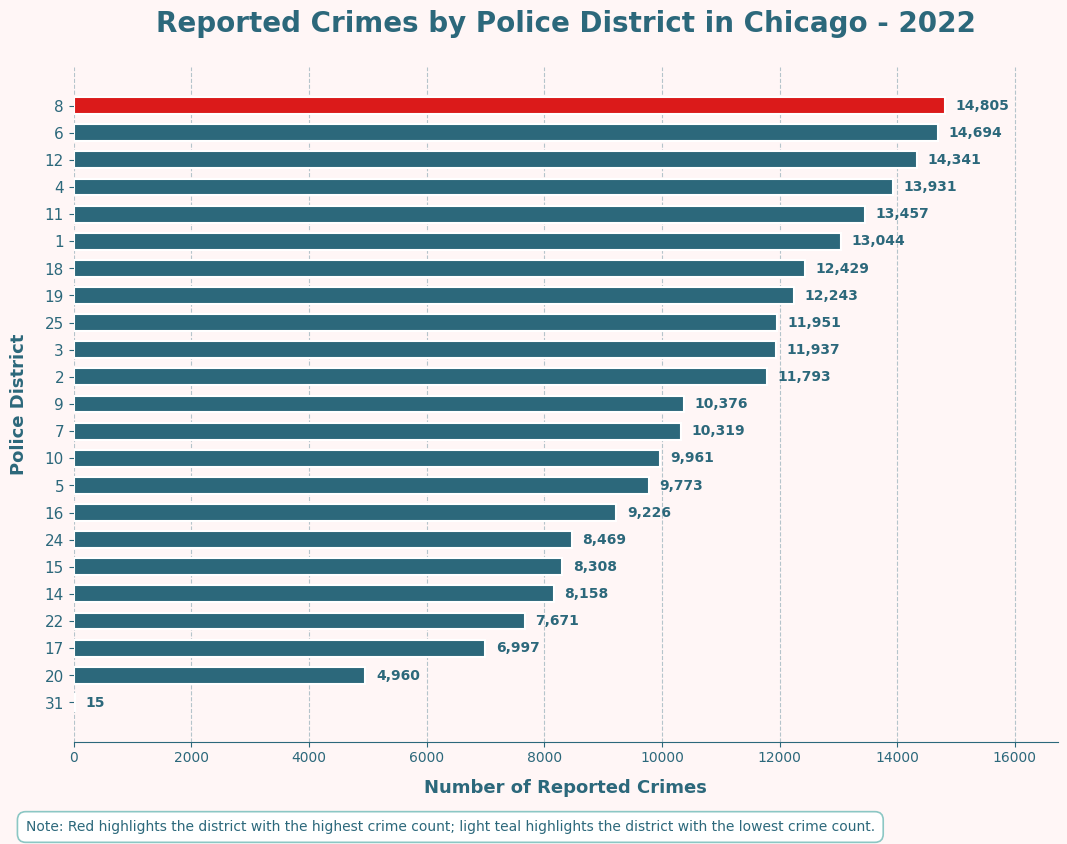

In [38]:
# Professional chart style colors
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

# Sort districts from lowest to highest for horizontal bar chart
plot_data = district_2022_counts.sort_values()

# Highlight highest and lowest districts
bar_colors = []
for district in plot_data.index:
    if district == district_2022_counts.idxmax():
        bar_colors.append(RED)
    elif district == district_2022_counts.idxmin():
        bar_colors.append(TEAL)
    else:
        bar_colors.append(DARK_TEAL)

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_data.index.astype(int).astype(str),
    plot_data.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=1.5,
    height=0.62
)

# Add value labels
max_value = plot_data.max()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_value * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10,
        color=DARK_TEAL,
        fontweight="bold"
    )

# Titles and labels
ax.set_title(
    "Reported Crimes by Police District in Chicago - 2022",
    fontsize=20,
    fontweight="bold",
    color=DARK_TEAL,
    pad=25
)

ax.set_xlabel(
    "Number of Reported Crimes",
    fontsize=13,
    color=DARK_TEAL,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Police District",
    fontsize=13,
    color=DARK_TEAL,
    fontweight="bold",
    labelpad=12
)

# Grid styling
ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

# Remove unnecessary borders
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(DARK_TEAL)

ax.tick_params(axis="x", colors=DARK_TEAL, labelsize=10)
ax.tick_params(axis="y", colors=DARK_TEAL, labelsize=11)

# Give extra space on the right for labels
ax.set_xlim(0, max_value * 1.13)

# Add clean note below chart with padding
note_text = (
    "Note: Red highlights the district with the highest crime count; "
    "light teal highlights the district with the lowest crime count."
)

fig.text(
    0.08, 0.035,
    note_text,
    ha="left",
    va="center",
    fontsize=10,
    color=DARK_TEAL,
    bbox=dict(
        facecolor="white",
        edgecolor=TEAL,
        boxstyle="round,pad=0.6",
        linewidth=1.2
    )
)

# Adjust layout to leave space for note
plt.subplots_adjust(left=0.12, right=0.94, top=0.88, bottom=0.13)

plt.show()

# Topic 1: Comparing Police Districts

### 1. Methodology
This analysis compares the number of reported crimes across Chicago police districts during 2022.
* **Data Filtering:** Includes only crimes reported in the year 2022.
* **Data Grouping:** Metrics are aggregated by individual police district.

---

### 2. Key Findings
* **Highest Crime Count:** District 8, with a total of **14,805 reported crimes**.
* **Lowest Crime Count:** District 31, with a total of **15 reported crimes**.

---

### 3. Analysis & Observations
The visualization indicates that crime distribution is not uniform across police districts:
* High-density crime counts are concentrated in specific areas, notably **District 8**, **District 6**, and **District 12**.
* Conversely, several other districts exhibit significantly lower reporting volumes.

### 4. Contributing Factors
The observed variance in crime distribution may be attributed to:
* Population density and demographics
* District-specific commercial and social activity
* Variations in public reporting patterns
* Geographic and administrative district boundaries


#**Topic 2: Crimes Across the Years**

##Is the total number of crimes increasing or decreasing across the years?

##Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

##Total crimes by year

In [39]:
# Count total crimes per year
annual_total = df.resample("YE").size()

# Convert datetime year-end index to year numbers
annual_total.index = annual_total.index.year

annual_total

,0
Datetime,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


##Visualization

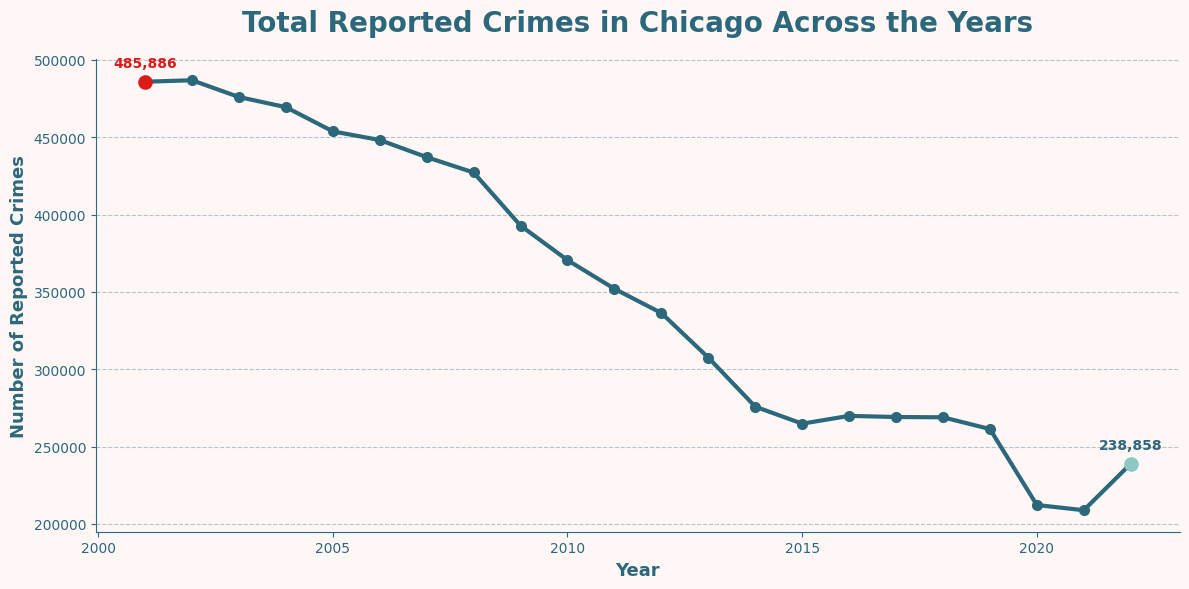

In [47]:
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

ax.plot(
    annual_total.index,
    annual_total.values,
    marker="o",
    linewidth=3,
    markersize=7,
    color=DARK_TEAL
)

# Highlight first and last year
ax.scatter(annual_total.index[0], annual_total.iloc[0], color=RED, s=90, zorder=5)
ax.scatter(annual_total.index[-1], annual_total.iloc[-1], color=TEAL, s=90, zorder=5)

# Add value labels for first and last year
ax.text(
    annual_total.index[0],
    annual_total.iloc[0] + annual_total.max()*0.02,
    f"{annual_total.iloc[0]:,}",
    ha="center",
    color=RED,
    fontweight="bold"
)

ax.text(
    annual_total.index[-1],
    annual_total.iloc[-1] + annual_total.max()*0.02,
    f"{annual_total.iloc[-1]:,}",
    ha="center",
    color=DARK_TEAL,
    fontweight="bold"
)

ax.set_title(
    "Total Reported Crimes in Chicago Across the Years",
    fontsize=20,
    fontweight="bold",
    color=DARK_TEAL,
    pad=20
)

ax.set_xlabel("Year", fontsize=13, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Number of Reported Crimes", fontsize=13, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(DARK_TEAL)
ax.spines["left"].set_color(DARK_TEAL)

ax.tick_params(axis="x", colors=DARK_TEAL)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

##We calculate whether the general trend has increased or decreased.

In [41]:
first_year = annual_total.index.min()
last_year = annual_total.index.max()

first_year_count = annual_total.loc[first_year]
last_year_count = annual_total.loc[last_year]

overall_change = last_year_count - first_year_count
overall_pct_change = (overall_change / first_year_count) * 100

print(f"First year: {first_year} = {first_year_count:,} crimes")
print(f"Last year: {last_year} = {last_year_count:,} crimes")
print(f"Overall change: {overall_change:,} crimes")
print(f"Percent change: {overall_pct_change:.2f}%")

if overall_change > 0:
    print("Overall trend: Increasing")
else:
    print("Overall trend: Decreasing")

First year: 2001 = 485,886 crimes
Last year: 2022 = 238,858 crimes
Overall change: -247,028 crimes
Percent change: -50.84%
Overall trend: Decreasing


##Types of crimes: Which increased and which decreased?

In [42]:
crime_by_year = (
    df.groupby("Primary Type")
    .resample("YE")
    .size()
    .reset_index(name="Crime Count")
)

crime_by_year["Year"] = crime_by_year["Datetime"].dt.year

crime_year_pivot = crime_by_year.pivot(
    index="Year",
    columns="Primary Type",
    values="Crime Count"
).fillna(0)

crime_year_pivot.head()

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,DOMESTIC VIOLENCE,GAMBLING,HOMICIDE,HUMAN TRAFFICKING,INTERFERENCE WITH PUBLIC OFFICER,INTIMIDATION,KIDNAPPING,LIQUOR LAW VIOLATION,MOTOR VEHICLE THEFT,NARCOTICS,NON - CRIMINAL,NON-CRIMINAL,NON-CRIMINAL (SUBJECT SPECIFIED),OBSCENITY,OFFENSE INVOLVING CHILDREN,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001,1011.0,31384.0,93461.0,26014.0,1.0,1779.0,55859.0,29.0,13241.0,14949.0,1.0,934.0,667.0,0.0,406.0,279.0,933.0,1637.0,27553.0,50567.0,0.0,0.0,0.0,19.0,2263.0,6.0,29662.0,6026.0,9.0,2750.0,8.0,18441.0,2239.0,204.0,99277.0,4277.0
2002,1032.0,31523.0,94153.0,25623.0,0.0,1807.0,55941.0,27.0,13880.0,13732.0,0.0,971.0,658.0,0.0,361.0,337.0,829.0,1414.0,25121.0,51789.0,0.0,0.0,0.0,26.0,2594.0,5.0,32600.0,6408.0,8.0,2457.0,2.0,18523.0,2173.0,200.0,98332.0,4281.0
2003,955.0,29477.0,88380.0,25157.0,0.0,1571.0,55011.0,41.0,14807.0,13459.0,0.0,1088.0,604.0,0.0,409.0,364.0,705.0,1311.0,22748.0,54288.0,0.0,1.0,0.0,16.0,3047.0,2.0,31148.0,6214.0,6.0,2430.0,2.0,17332.0,2078.0,247.0,98876.0,4211.0
2004,778.0,28850.0,87136.0,24564.0,0.0,1538.0,53164.0,42.0,15913.0,13255.0,0.0,1122.0,455.0,0.0,531.0,349.0,482.0,985.0,22805.0,57060.0,0.0,0.0,0.0,13.0,3099.0,9.0,29532.0,7476.0,9.0,2495.0,1.0,15978.0,1805.0,215.0,95463.0,4298.0
2005,691.0,27067.0,83964.0,25503.0,0.0,1521.0,54548.0,37.0,16655.0,13590.0,0.0,1078.0,453.0,0.0,615.0,258.0,389.0,1005.0,22497.0,56234.0,0.0,0.0,0.0,19.0,2906.0,9.0,28028.0,6124.0,4.0,2730.0,2.0,16047.0,1817.0,192.0,85684.0,4106.0


##Calculating the change for each type of crime

In [43]:
crime_change = pd.DataFrame({
    "First Year Count": crime_year_pivot.loc[first_year],
    "Last Year Count": crime_year_pivot.loc[last_year]
})

crime_change["Change"] = crime_change["Last Year Count"] - crime_change["First Year Count"]

crime_change["Percent Change"] = np.where(
    crime_change["First Year Count"] > 0,
    (crime_change["Change"] / crime_change["First Year Count"]) * 100,
    np.nan
)

crime_change = crime_change.sort_values("Change", ascending=False)

crime_change

,First Year Count,Last Year Count,Change,Percent Change
Primary Type,,,,
WEAPONS VIOLATION,4277.0,8766.0,4489.0,104.956745
CRIMINAL SEXUAL ASSAULT,29.0,1559.0,1530.0,5275.862069
DECEPTIVE PRACTICE,14949.0,16405.0,1456.0,9.739782
STALKING,204.0,446.0,242.0,118.627451
CONCEALED CARRY LICENSE VIOLATION,1.0,177.0,176.0,17600.000000
HOMICIDE,667.0,725.0,58.0,8.695652
OBSCENITY,19.0,49.0,30.0,157.894737
HUMAN TRAFFICKING,0.0,17.0,17.0,NaN
NON-CRIMINAL,0.0,5.0,5.0,NaN


##Crimes that go against the general trend

In [44]:
if overall_change < 0:
    opposite_crimes = crime_change[crime_change["Change"] > 0].sort_values("Change", ascending=False)
else:
    opposite_crimes = crime_change[crime_change["Change"] < 0].sort_values("Change")

opposite_crimes

,First Year Count,Last Year Count,Change,Percent Change
Primary Type,,,,
WEAPONS VIOLATION,4277.0,8766.0,4489.0,104.956745
CRIMINAL SEXUAL ASSAULT,29.0,1559.0,1530.0,5275.862069
DECEPTIVE PRACTICE,14949.0,16405.0,1456.0,9.739782
STALKING,204.0,446.0,242.0,118.627451
CONCEALED CARRY LICENSE VIOLATION,1.0,177.0,176.0,17600.000000
HOMICIDE,667.0,725.0,58.0,8.695652
OBSCENITY,19.0,49.0,30.0,157.894737
HUMAN TRAFFICKING,0.0,17.0,17.0,NaN
NON-CRIMINAL,0.0,5.0,5.0,NaN


##Visualization

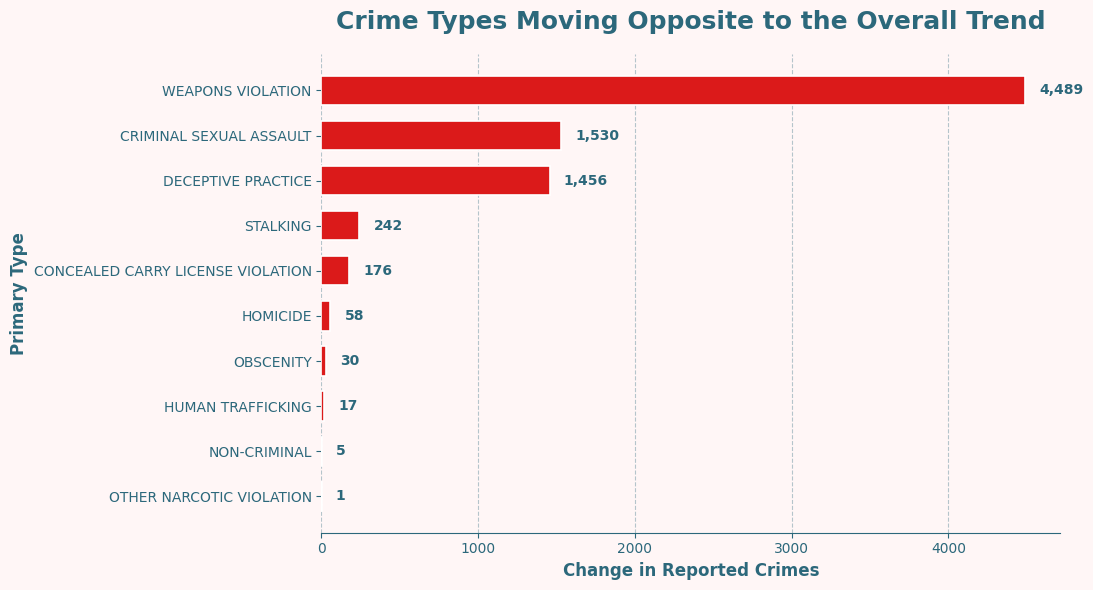

In [45]:
plot_opposite = opposite_crimes.head(10).sort_values("Change")

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)

ax.barh(
    plot_opposite.index,
    plot_opposite["Change"],
    color=RED,
    edgecolor="white",
    linewidth=1.2,
    height=0.65
)

for i, value in enumerate(plot_opposite["Change"]):
    ax.text(
        value + (plot_opposite["Change"].max() * 0.02),
        i,
        f"{int(value):,}",
        va="center",
        fontsize=10,
        color=DARK_TEAL,
        fontweight="bold"
    )

ax.set_title(
    "Crime Types Moving Opposite to the Overall Trend",
    fontsize=18,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_xlabel("Change in Reported Crimes", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Primary Type", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(DARK_TEAL)
ax.tick_params(axis="x", colors=DARK_TEAL)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

In [48]:
annual_total

,0
Datetime,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


In [49]:
opposite_crimes.head(10)

,First Year Count,Last Year Count,Change,Percent Change
Primary Type,,,,
WEAPONS VIOLATION,4277.0,8766.0,4489.0,104.956745
CRIMINAL SEXUAL ASSAULT,29.0,1559.0,1530.0,5275.862069
DECEPTIVE PRACTICE,14949.0,16405.0,1456.0,9.739782
STALKING,204.0,446.0,242.0,118.627451
CONCEALED CARRY LICENSE VIOLATION,1.0,177.0,176.0,17600.000000
HOMICIDE,667.0,725.0,58.0,8.695652
OBSCENITY,19.0,49.0,30.0,157.894737
HUMAN TRAFFICKING,0.0,17.0,17.0,NaN
NON-CRIMINAL,0.0,5.0,5.0,NaN


# Topic 2: Crimes Across the Years

### 1. Methodology
This analysis examines the temporal trajectory of reported crimes in Chicago from 2001 to 2022.
* **Data Aggregation:** The dataset was grouped by year to compute the annual aggregate of reported offenses.
* **Objective:** To determine the long-term macro trends in criminal activity over a 21-year period.

---

### 2. Macro Trend Analysis (2001 vs. 2022)
The empirical data indicates a substantial downward trend in overall reported crimes:
* **Volume in 2001:** 485,886 reported crimes.
* **Volume in 2022:** 238,858 reported crimes.
* **Net Reduction:** **247,028 offenses** (a percentage decrease of approximately **50.84%**).

---

### 3. Micro Trends: Increasing Crime Categories
While the aggregate crime rate decreased, specific offense categories experienced divergent upward trends. The most significant net increases include:

* **Weapons Violation:** +4,489 crimes
* **Criminal Sexual Assault:** +1,530 crimes
* **Deceptive Practice:** +1,456 crimes
* **Stalking:** +242 crimes
* **Concealed Carry License Violation:** +176 crimes
* **Homicide:** +58 crimes

---

### 4. Critical Analytical Insights
* **Divergent Patterns:** Aggregate declines do not imply uniform reductions across all crime types; specific offenses may fluctuate due to shifts in criminal behavior, law enforcement focus, or societal changes.


#**Topic 3: AM vs PM Rush Hour**

##Are crimes more common during AM rush hour or PM rush hour?


##What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?


##Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

##Creating a Rush Hour Column

In [50]:
# Make sure Hour column exists
df["Hour"] = df.index.hour

# Create Rush Hour column
df["Rush Hour"] = "Other"

df.loc[(df["Hour"] >= 7) & (df["Hour"] < 10), "Rush Hour"] = "AM Rush Hour"
df.loc[(df["Hour"] >= 16) & (df["Hour"] < 19), "Rush Hour"] = "PM Rush Hour"

# Keep only rush hour crimes
rush_df = df[df["Rush Hour"].isin(["AM Rush Hour", "PM Rush Hour"])].copy()

rush_df[["Primary Type", "Hour", "Rush Hour"]].head()

,Primary Type,Hour,Rush Hour
Datetime,,,
2001-01-01 07:00:00,THEFT,7,AM Rush Hour
2001-01-01 07:00:00,THEFT,7,AM Rush Hour
2001-01-01 07:00:00,MOTOR VEHICLE THEFT,7,AM Rush Hour
2001-01-01 07:00:00,BATTERY,7,AM Rush Hour
2001-01-01 07:00:00,BURGLARY,7,AM Rush Hour


##Are crimes more common in AM or PM?

In [51]:
rush_counts = rush_df["Rush Hour"].value_counts()

rush_counts

,count
Rush Hour,
PM Rush Hour,1206353
AM Rush Hour,770651


##Visualization

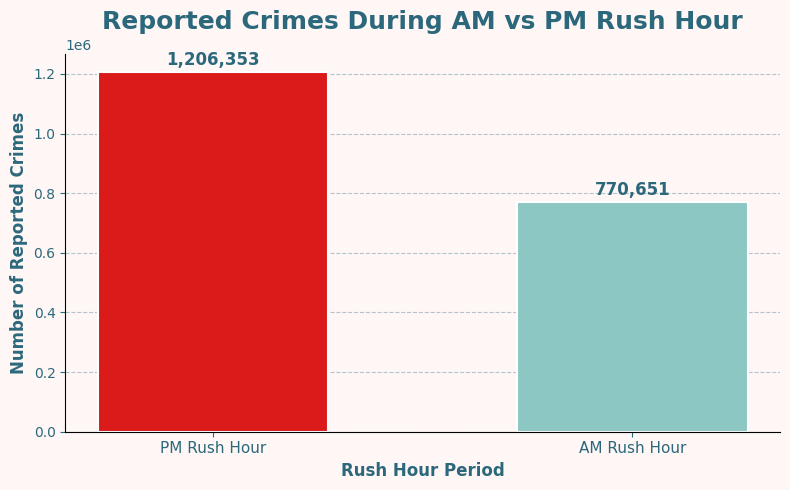

In [52]:
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)

colors = [TEAL if label == "AM Rush Hour" else RED for label in rush_counts.index]

bars = ax.bar(
    rush_counts.index,
    rush_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + rush_counts.max()*0.02,
        f"{int(height):,}",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Reported Crimes During AM vs PM Rush Hour",
    fontsize=18,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_ylabel("Number of Reported Crimes", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_xlabel("Rush Hour Period", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", colors=DARK_TEAL, labelsize=11)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

#Top 5 crimes in AM Rush Hour

In [53]:
am_top5 = (
    rush_df[rush_df["Rush Hour"] == "AM Rush Hour"]["Primary Type"]
    .value_counts()
    .head(5)
)

am_top5

,count
Primary Type,
THEFT,185239
BATTERY,108199
CRIMINAL DAMAGE,81281
BURGLARY,73999
OTHER OFFENSE,62453


#Top 5 crimes in PM Rush Hour

In [55]:
pm_top5 = (
    rush_df[rush_df["Rush Hour"] == "PM Rush Hour"]["Primary Type"]
    .value_counts()
    .head(5)
)

pm_top5

,count
Primary Type,
THEFT,293514
BATTERY,213002
CRIMINAL DAMAGE,134101
NARCOTICS,103032
ASSAULT,89600


#Top 5 AM vs PM

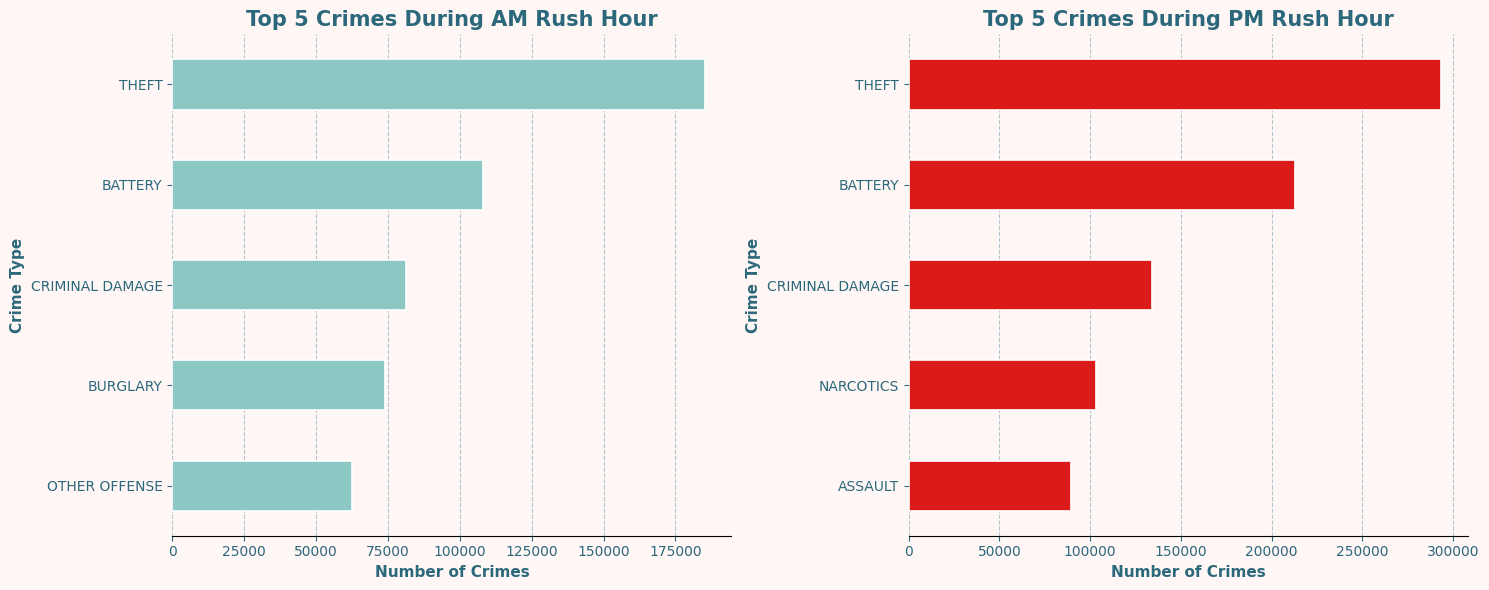

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)

for ax in axes:
    ax.set_facecolor(BG)

# AM chart
am_top5.sort_values().plot(
    kind="barh",
    ax=axes[0],
    color=TEAL,
    edgecolor="white",
    linewidth=1.2
)

axes[0].set_title("Top 5 Crimes During AM Rush Hour", fontsize=15, fontweight="bold", color=DARK_TEAL)
axes[0].set_xlabel("Number of Crimes", fontsize=11, color=DARK_TEAL, fontweight="bold")
axes[0].set_ylabel("Crime Type", fontsize=11, color=DARK_TEAL, fontweight="bold")

# PM chart
pm_top5.sort_values().plot(
    kind="barh",
    ax=axes[1],
    color=RED,
    edgecolor="white",
    linewidth=1.2
)

axes[1].set_title("Top 5 Crimes During PM Rush Hour", fontsize=15, fontweight="bold", color=DARK_TEAL)
axes[1].set_xlabel("Number of Crimes", fontsize=11, color=DARK_TEAL, fontweight="bold")
axes[1].set_ylabel("Crime Type", fontsize=11, color=DARK_TEAL, fontweight="bold")

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", colors=DARK_TEAL)
    ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

##Motor Vehicle Theft: AM or PM more?

In [57]:
motor_vehicle_theft = rush_df[
    rush_df["Primary Type"] == "MOTOR VEHICLE THEFT"
]["Rush Hour"].value_counts()

motor_vehicle_theft

,count
Rush Hour,
PM Rush Hour,53716
AM Rush Hour,41578


##Visulization

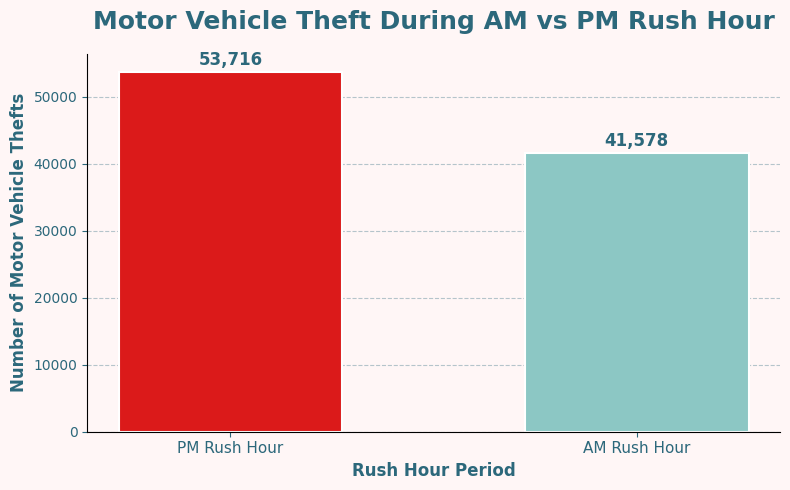

In [58]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)

colors = [TEAL if label == "AM Rush Hour" else RED for label in motor_vehicle_theft.index]

bars = ax.bar(
    motor_vehicle_theft.index,
    motor_vehicle_theft.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + motor_vehicle_theft.max()*0.02,
        f"{int(height):,}",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Motor Vehicle Theft During AM vs PM Rush Hour",
    fontsize=18,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_ylabel("Number of Motor Vehicle Thefts", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_xlabel("Rush Hour Period", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", colors=DARK_TEAL, labelsize=11)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

## Topic 3: Comparing AM vs PM Rush Hour

This analysis compares reported crimes during morning and evening rush hours in Chicago.

For this project:

* **AM Rush Hour** includes crimes from **7:00 AM to before 10:00 AM**.
* **PM Rush Hour** includes crimes from **4:00 PM to before 7:00 PM**.

The results show that crimes are more common during **PM Rush Hour**. There were **1,206,353 reported crimes** during PM rush hour, compared to **770,651 reported crimes** during AM rush hour.

The top 5 most common crimes during **AM Rush Hour** were:

1. **Theft**
2. **Battery**
3. **Criminal Damage**
4. **Burglary**
5. **Other Offense**

The top 5 most common crimes during **PM Rush Hour** were:

1. **Theft**
2. **Battery**
3. **Criminal Damage**
4. **Narcotics**
5. **Assault**

For **Motor Vehicle Theft**, the crime was also more common during **PM Rush Hour**, with **53,716 cases**, compared to **41,578 cases** during AM Rush Hour.

Overall, the analysis shows that PM rush hour has higher crime activity than AM rush hour, both in total reported crimes and in Motor Vehicle Theft.


#**Topic 4: Comparing Holidays**

##What are the top 3 holidays with the largest number of crimes?

##For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

##We add the fault to the data

In [59]:
!pip install holidays -q

from holidays import country_holidays

# Create U.S. holidays object
us_holidays = country_holidays("US")

# Create a date-only column from the datetime index
df["DateOnly"] = df.index.date

# Create a holiday lookup dictionary for unique dates only
unique_dates = df["DateOnly"].unique()
holiday_map = {date: us_holidays.get(date) for date in unique_dates}

# Add holiday name to each row
df["Holiday"] = df["DateOnly"].map(holiday_map)

df[["Primary Type", "DateOnly", "Holiday"]].head()

,Primary Type,DateOnly,Holiday
Datetime,,,
2001-01-01,THEFT,2001-01-01,New Year's Day
2001-01-01,THEFT,2001-01-01,New Year's Day
2001-01-01,OFFENSE INVOLVING CHILDREN,2001-01-01,New Year's Day
2001-01-01,THEFT,2001-01-01,New Year's Day
2001-01-01,SEX OFFENSE,2001-01-01,New Year's Day


##We only filter crimes that occurred during the holiday.

In [60]:
holiday_df = df.dropna(subset=["Holiday"]).copy()

holiday_df[["Primary Type", "Holiday"]].head()

,Primary Type,Holiday
Datetime,,
2001-01-01,THEFT,New Year's Day
2001-01-01,THEFT,New Year's Day
2001-01-01,OFFENSE INVOLVING CHILDREN,New Year's Day
2001-01-01,THEFT,New Year's Day
2001-01-01,SEX OFFENSE,New Year's Day


##We are checking how many crimes occurred during the holidays:

In [61]:
holiday_df.shape

(227138, 19)

##Top 3 holidays with crime incidents

In [62]:
top_holidays = holiday_df["Holiday"].value_counts().head(3)

top_holidays

,count
Holiday,
New Year's Day,32725
Independence Day,22672
Labor Day,22164


## Visulizatio of the top 3 holidays

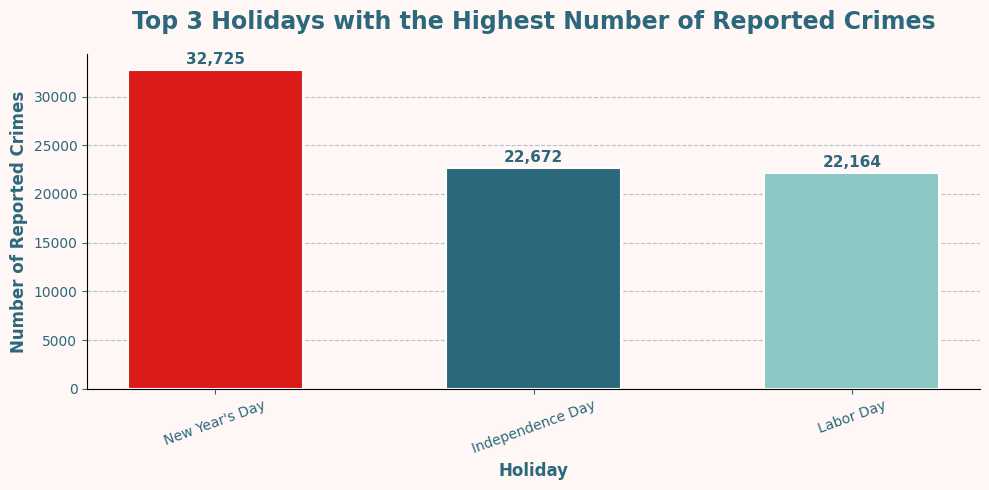

In [63]:
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
ax.set_facecolor(BG)

colors = [RED, DARK_TEAL, TEAL]

bars = ax.bar(
    top_holidays.index,
    top_holidays.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + top_holidays.max()*0.02,
        f"{int(height):,}",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Top 3 Holidays with the Highest Number of Reported Crimes",
    fontsize=17,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_xlabel("Holiday", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Number of Reported Crimes", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", colors=DARK_TEAL, labelrotation=20)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

##The top 5 most common crimes during each holiday, from the top 3

In [64]:
top_holiday_names = top_holidays.index

top5_crimes_by_holiday = {}

for holiday in top_holiday_names:
    top5 = (
        holiday_df[holiday_df["Holiday"] == holiday]["Primary Type"]
        .value_counts()
        .head(5)
    )
    top5_crimes_by_holiday[holiday] = top5
    print(f"\nTop 5 crimes on {holiday}:")
    display(top5)


Top 5 crimes on New Year's Day:


,count
Primary Type,
THEFT,6845
BATTERY,6043
CRIMINAL DAMAGE,3236
DECEPTIVE PRACTICE,2934
OFFENSE INVOLVING CHILDREN,2380



Top 5 crimes on Independence Day:


,count
Primary Type,
BATTERY,5805
THEFT,4074
CRIMINAL DAMAGE,3309
ASSAULT,1547
NARCOTICS,1522



Top 5 crimes on Labor Day:


,count
Primary Type,
BATTERY,4607
THEFT,4520
CRIMINAL DAMAGE,2475
NARCOTICS,2078
ASSAULT,1525


## Visulizatio for Top 5 for every holiday

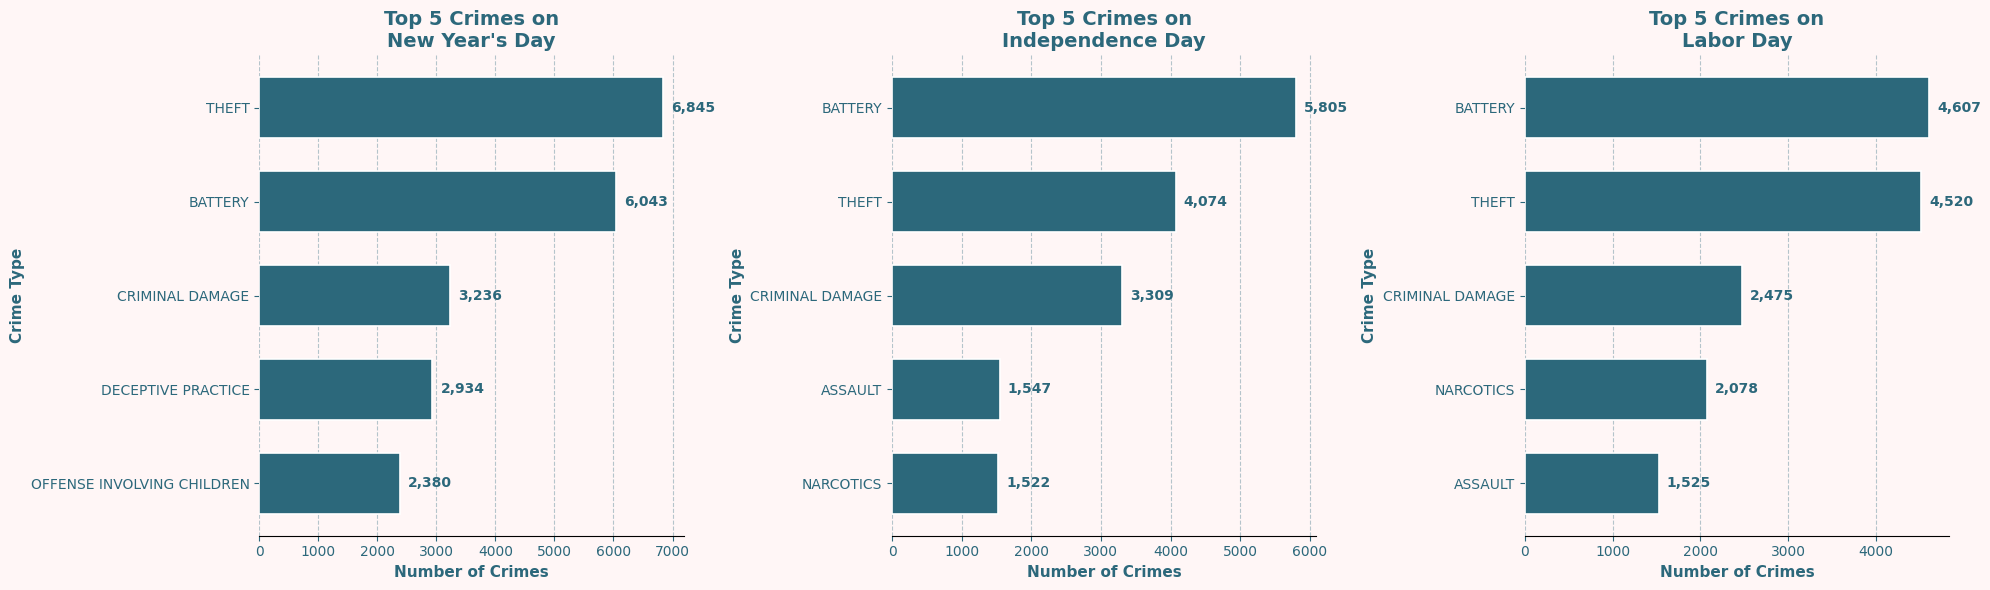

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG)

for ax, holiday in zip(axes, top_holiday_names):
    ax.set_facecolor(BG)

    data = top5_crimes_by_holiday[holiday].sort_values()

    ax.barh(
        data.index,
        data.values,
        color=DARK_TEAL,
        edgecolor="white",
        linewidth=1.2,
        height=0.65
    )

    for i, value in enumerate(data.values):
        ax.text(
            value + data.max()*0.02,
            i,
            f"{int(value):,}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=DARK_TEAL
        )

    ax.set_title(
        f"Top 5 Crimes on\n{holiday}",
        fontsize=14,
        fontweight="bold",
        color=DARK_TEAL
    )

    ax.set_xlabel("Number of Crimes", fontsize=11, color=DARK_TEAL, fontweight="bold")
    ax.set_ylabel("Crime Type", fontsize=11, color=DARK_TEAL, fontweight="bold")

    ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", colors=DARK_TEAL)
    ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

## Topic 4: Comparing Holidays

This analysis examines reported crimes that occurred on U.S. holidays in Chicago. The holiday feature was added using the `holidays` package, then the data was filtered to include only crimes reported on holidays.

The top 3 holidays with the highest number of reported crimes were:

1. **New Year's Day** with **32,725 crimes**
2. **Independence Day** with **22,672 crimes**
3. **Labor Day** with **22,164 crimes**

For **New Year's Day**, the top 5 most common crimes were:

* **Theft:** 6,845
* **Battery:** 6,043
* **Criminal Damage:** 3,236
* **Deceptive Practice:** 2,934
* **Offense Involving Children:** 2,380

For **Independence Day**, the top 5 most common crimes were:

* **Battery:** 5,805
* **Theft:** 4,074
* **Criminal Damage:** 3,309
* **Assault:** 1,547
* **Narcotics:** 1,522

For **Labor Day**, the top 5 most common crimes were:

* **Battery:** 4,607
* **Theft:** 4,520
* **Criminal Damage:** 2,475
* **Narcotics:** 2,078
* **Assault:** 1,525

Overall, **New Year's Day had the highest number of reported crimes** among all holidays. Theft was the most common crime on New Year's Day, while Battery was the most common crime on both Independence Day and Labor Day.


# Overall Conclusion

This project analyzed reported crime incidents in Chicago from 2001 to 2022 using time series analysis techniques. The goal was to answer stakeholder questions for a local newspaper reporter and support the findings with clear visualizations.

The analysis showed several important findings:

1. **Police Districts:**
   In 2022, crime was not evenly distributed across police districts. District 8 had the highest number of reported crimes, while District 31 had the lowest.

2. **Crime Trends Across the Years:**
   Total reported crimes decreased significantly from 2001 to 2022. Reported crimes dropped from 485,886 in 2001 to 238,858 in 2022, which is about a 50.84% decrease. However, some crime types increased despite the overall decline, such as Weapons Violation, Deceptive Practice, Criminal Sexual Assault, and Homicide.

3. **AM vs PM Rush Hour:**
   Crimes were more common during PM rush hour than AM rush hour. Theft was the most common crime during both periods. Motor Vehicle Theft was also more common during PM rush hour.

4. **Holidays:**
   New Year's Day had the highest number of reported crimes among holidays, followed by Independence Day and Labor Day. Theft was the most common crime on New Year's Day, while Battery was the most common crime on Independence Day and Labor Day.

Overall, this project shows that crime patterns in Chicago vary by time, location, crime type, and special calendar events. Time series analysis helped turn raw crime records into meaningful insights that can support public reporting and stakeholder decision-making.


**In addition to the original crime-level dataset, I created a daily resampled version where each row represents one day and the value represents the total number of reported crimes on that day.**

In [68]:
daily_counts = df.resample("D").size().to_frame("Total Crimes")

daily_counts.head()

,Total Crimes
Datetime,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


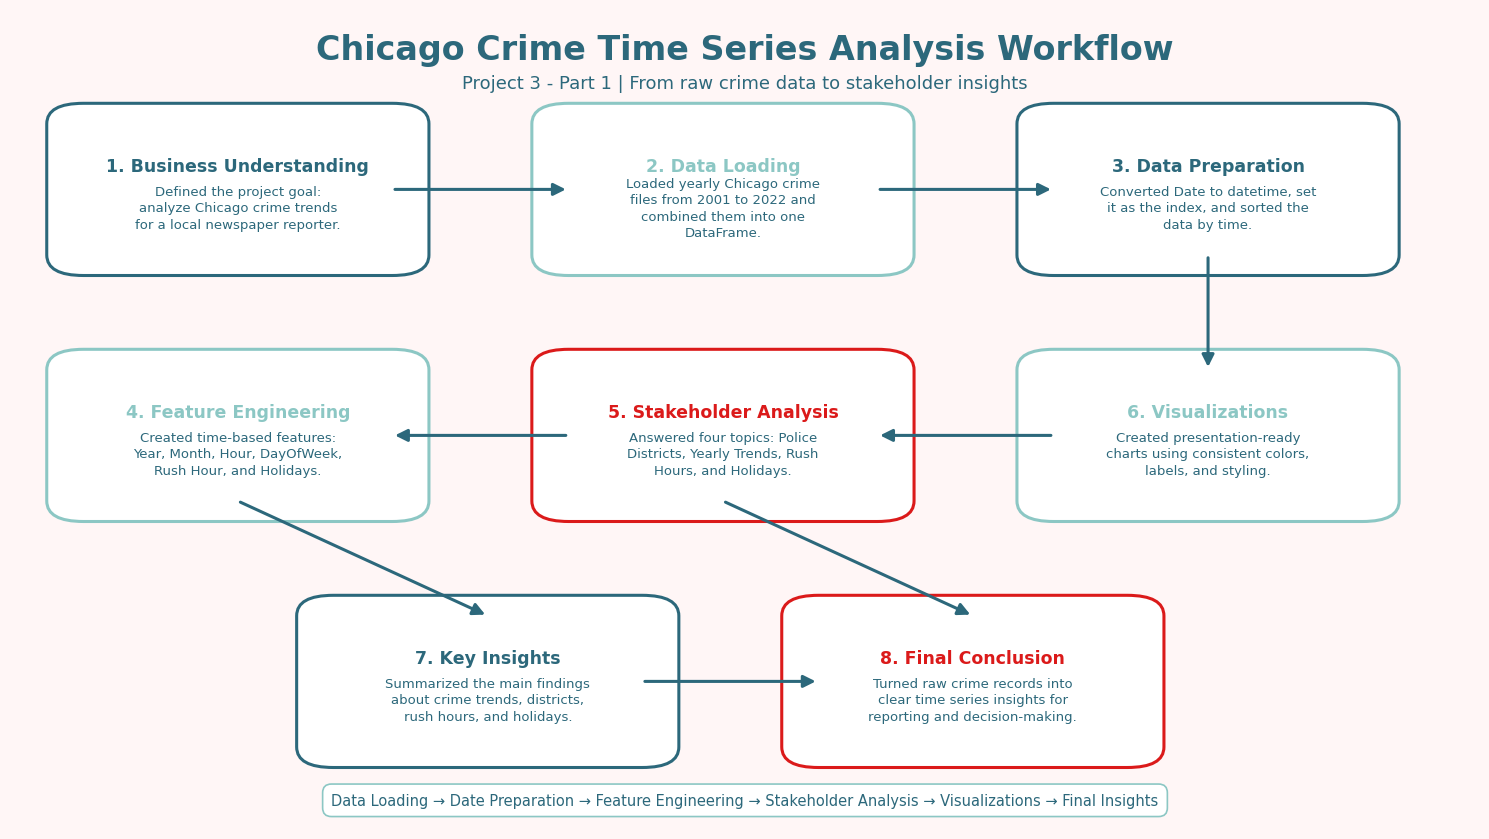

In [74]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import textwrap

# Color palette
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(15, 8.5), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

def wrap_text(text, width=28):
    return "\n".join(textwrap.wrap(text, width=width))

steps = [
    {
        "title": "1. Business Understanding",
        "text": "Defined the project goal: analyze Chicago crime trends for a local newspaper reporter.",
        "x": 0.05, "y": 0.70, "color": DARK_TEAL
    },
    {
        "title": "2. Data Loading",
        "text": "Loaded yearly Chicago crime files from 2001 to 2022 and combined them into one DataFrame.",
        "x": 0.38, "y": 0.70, "color": TEAL
    },
    {
        "title": "3. Data Preparation",
        "text": "Converted Date to datetime, set it as the index, and sorted the data by time.",
        "x": 0.71, "y": 0.70, "color": DARK_TEAL
    },
    {
        "title": "4. Feature Engineering",
        "text": "Created time-based features: Year, Month, Hour, DayOfWeek, Rush Hour, and Holidays.",
        "x": 0.05, "y": 0.40, "color": TEAL
    },
    {
        "title": "5. Stakeholder Analysis",
        "text": "Answered four topics: Police Districts, Yearly Trends, Rush Hours, and Holidays.",
        "x": 0.38, "y": 0.40, "color": RED
    },
    {
        "title": "6. Visualizations",
        "text": "Created presentation-ready charts using consistent colors, labels, and styling.",
        "x": 0.71, "y": 0.40, "color": TEAL
    },
    {
        "title": "7. Key Insights",
        "text": "Summarized the main findings about crime trends, districts, rush hours, and holidays.",
        "x": 0.22, "y": 0.10, "color": DARK_TEAL
    },
    {
        "title": "8. Final Conclusion",
        "text": "Turned raw crime records into clear time series insights for reporting and decision-making.",
        "x": 0.55, "y": 0.10, "color": RED
    },
]

box_w = 0.21
box_h = 0.16

# Draw boxes and text
for step in steps:
    box = FancyBboxPatch(
        (step["x"], step["y"]),
        box_w,
        box_h,
        boxstyle="round,pad=0.025,rounding_size=0.025",
        linewidth=2.2,
        edgecolor=step["color"],
        facecolor="white"
    )
    ax.add_patch(box)

    # Title
    ax.text(
        step["x"] + box_w/2,
        step["y"] + box_h*0.68,
        step["title"],
        ha="center",
        va="center",
        fontsize=12.5,
        fontweight="bold",
        color=step["color"]
    )

    # Wrapped text
    ax.text(
        step["x"] + box_w/2,
        step["y"] + box_h*0.36,
        wrap_text(step["text"], width=31),
        ha="center",
        va="center",
        fontsize=9.5,
        color=DARK_TEAL,
        linespacing=1.35
    )

def add_arrow(start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=2.2,
        color=DARK_TEAL
    )
    ax.add_patch(arrow)

# Arrows
add_arrow((0.05 + box_w, 0.70 + box_h/2), (0.38, 0.70 + box_h/2))
add_arrow((0.38 + box_w, 0.70 + box_h/2), (0.71, 0.70 + box_h/2))

add_arrow((0.71 + box_w/2, 0.70), (0.71 + box_w/2, 0.40 + box_h))

add_arrow((0.71, 0.40 + box_h/2), (0.38 + box_w, 0.40 + box_h/2))
add_arrow((0.38, 0.40 + box_h/2), (0.05 + box_w, 0.40 + box_h/2))

add_arrow((0.05 + box_w/2, 0.40), (0.22 + box_w/2, 0.10 + box_h))
add_arrow((0.38 + box_w/2, 0.40), (0.55 + box_w/2, 0.10 + box_h))

add_arrow((0.22 + box_w, 0.10 + box_h/2), (0.55, 0.10 + box_h/2))

# Main title
ax.text(
    0.5,
    0.95,
    "Chicago Crime Time Series Analysis Workflow",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color=DARK_TEAL
)

# Subtitle
ax.text(
    0.5,
    0.91,
    "Project 3 - Part 1 | From raw crime data to stakeholder insights",
    ha="center",
    va="center",
    fontsize=13,
    color=DARK_TEAL
)

# Footer
ax.text(
    0.5,
    0.035,
    "Data Loading → Date Preparation → Feature Engineering → Stakeholder Analysis → Visualizations → Final Insights",
    ha="center",
    va="center",
    fontsize=10.5,
    color=DARK_TEAL,
    bbox=dict(
        facecolor="white",
        edgecolor=TEAL,
        boxstyle="round,pad=0.6",
        linewidth=1.2
    )
)

plt.tight_layout()
plt.show()